<a href="https://colab.research.google.com/github/SIVAPRASAD03/Quantum/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Assignment 2: Quantum Gates, Circuits & Entanglement





In [5]:
!pip -q install qiskit qiskit-aer pylatexenc

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display, Markdown

SHOTS = 1024
simulator = AerSimulator()

def show_results(qc, title):
    """Show the circuit, statevector before measurement, counts and histogram."""
    print(title)
    display(qc.draw('mpl'))
    sv = Statevector.from_instruction(qc)
    print('Statevector (Qiskit basis order |q1 q0> for two qubits):', sv.data)
    measured = qc.copy()
    measured.measure_all()
    result = simulator.run(transpile(measured, simulator), shots=SHOTS).result()
    counts = result.get_counts()
    print('Counts:', counts)
    display(plot_histogram(counts, title=title))
    return sv, counts

def ket_single(a, b):
    return f'({a})|0> + ({b})|1>'

# Note: an overall minus sign is a global phase and does not change a physical state.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.4 MB/s eta 0:00:00


## 1. Single-Qubit Gate Order

### Circuit A: H → X → Z

Starting from \(|0\rangle\):

\[
|0\rangle \xrightarrow{H} \frac{|0\rangle+|1\rangle}{\sqrt2}=|+\rangle
\xrightarrow{X}|+\rangle
\xrightarrow{Z}\frac{|0\rangle-|1\rangle}{\sqrt2}=|-\rangle.
\]

### Circuit B: Z → X → H

\[
|0\rangle\xrightarrow{Z}|0\rangle\xrightarrow{X}|1\rangle
\xrightarrow{H}\frac{|0\rangle-|1\rangle}{\sqrt2}=|-\rangle.
\]

1A: H → X → Z


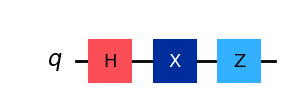

Statevector (Qiskit basis order |q1 q0> for two qubits): [ 0.70710678+0.j -0.70710678+0.j]
Counts: {'0': 501, '1': 523}


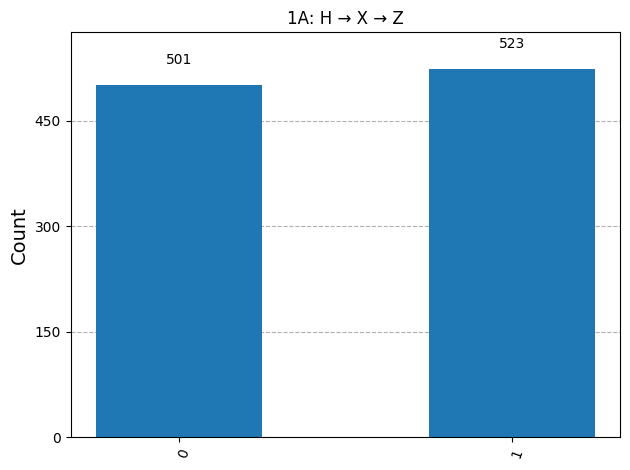

1B: Z → X → H


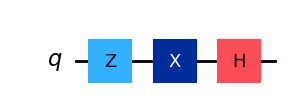

Statevector (Qiskit basis order |q1 q0> for two qubits): [ 0.70710678+0.j -0.70710678+0.j]
Counts: {'1': 511, '0': 513}


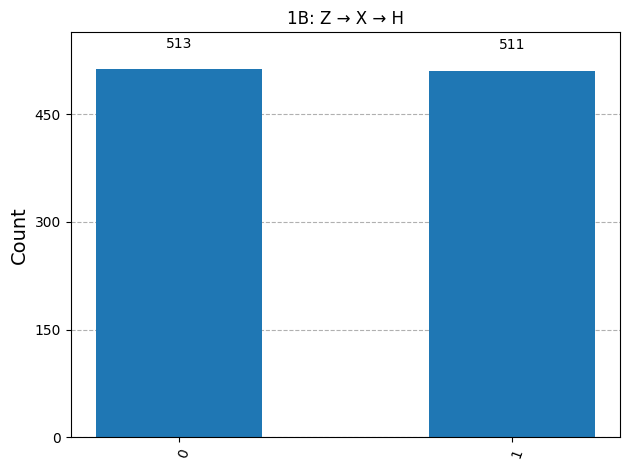

Are the final statevectors equal? True


In [6]:
qc_a = QuantumCircuit(1)
qc_a.h(0); qc_a.x(0); qc_a.z(0)
sv_a, counts_a = show_results(qc_a, '1A: H → X → Z')

qc_b = QuantumCircuit(1)
qc_b.z(0); qc_b.x(0); qc_b.h(0)
sv_b, counts_b = show_results(qc_b, '1B: Z → X → H')

print('Are the final statevectors equal?', np.allclose(sv_a.data, sv_b.data))

**Comparison:** Both circuits give \(|-\rangle=(|0\rangle-|1\rangle)/\sqrt2\), so their statevectors are equal. Measurements in the computational basis ignore the relative sign when calculating individual probabilities; therefore each circuit gives roughly 50% `0` and 50% `1`.

## 2. My Own Single-Qubit Circuit

I choose **H → X → H → X**. It has four gates and repeats both H and X.

\[
|0\rangle\xrightarrow H |+\rangle\xrightarrow X |+\rangle
\xrightarrow H |0\rangle\xrightarrow X |1\rangle.
\]

Prediction: every measurement should be `1`. A different sequence with the same final state is simply \(X|0\rangle=|1\rangle\).

2: H → X → H → X


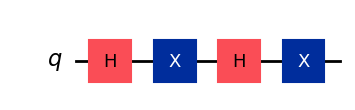

Statevector (Qiskit basis order |q1 q0> for two qubits): [0.+0.j 1.+0.j]
Counts: {'1': 1024}


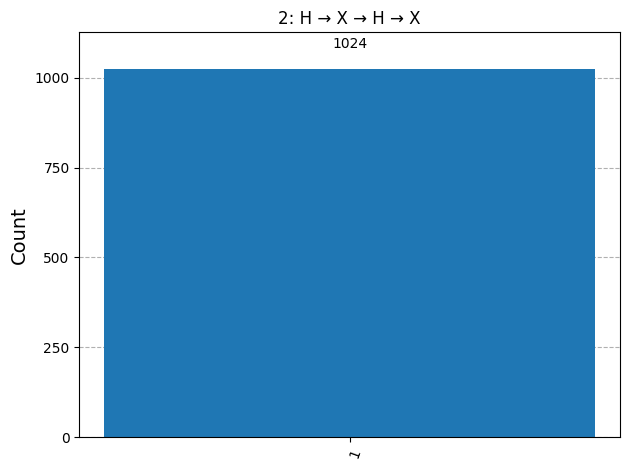

Prediction was |1>; probability of |1> = 0.9999999999999996


In [7]:
qc_own = QuantumCircuit(1)
qc_own.h(0); qc_own.x(0); qc_own.h(0); qc_own.x(0)
sv_own, counts_own = show_results(qc_own, '2: H → X → H → X')
print('Prediction was |1>; probability of |1> =', abs(sv_own.data[1])**2)

## 3. Investigating Two-Qubit Systems

Qiskit displays two-qubit basis strings as \(|q_1q_0\rangle\). In the descriptions below, the first wire is q0 and the second is q1.

**Circuit A:** H on each qubit gives \(|+\rangle\otimes|+\rangle=(|00\rangle+|01\rangle+|10\rangle+|11\rangle)/2\). This is separable because it is explicitly a product of two single-qubit states.

**Circuit B:** H on q0 followed by CNOT(q0→q1) gives \((|00\rangle+|11\rangle)/\sqrt2\). It is entangled: it cannot be factorised into one state for q0 times one state for q1.

3A: Independent superposition


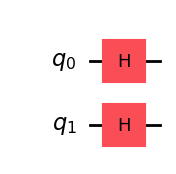

Statevector (Qiskit basis order |q1 q0> for two qubits): [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
Counts: {'11': 259, '10': 240, '00': 262, '01': 263}


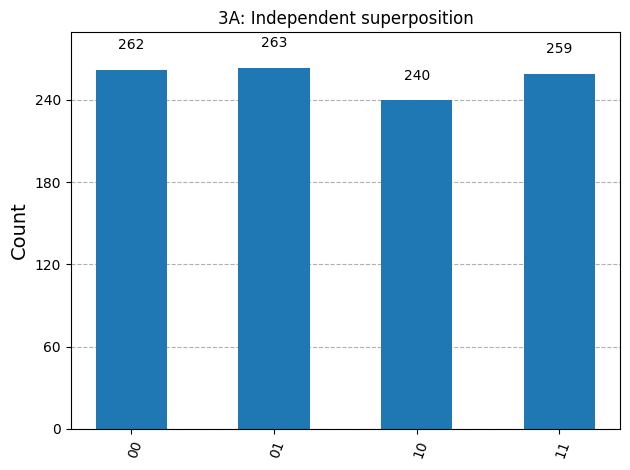

Possible outcomes: 00, 01, 10, 11 (each about 25%). Separable.
3B: Entangled state


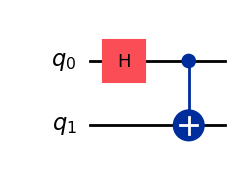

Statevector (Qiskit basis order |q1 q0> for two qubits): [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Counts: {'00': 506, '11': 518}


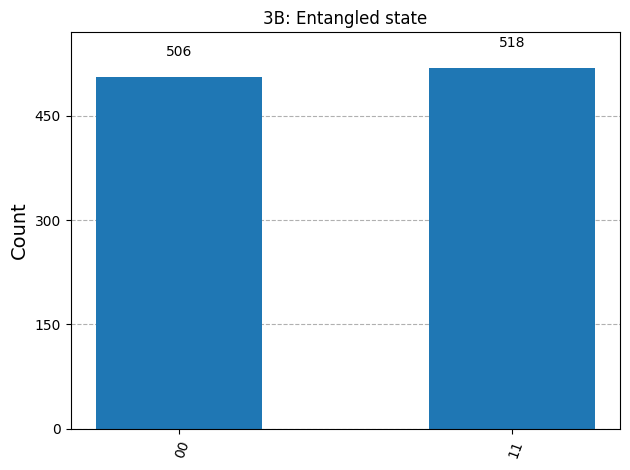

Possible outcomes: 00 and 11 (each about 50%). Entangled.


In [8]:
qc_independent = QuantumCircuit(2)
qc_independent.h(0); qc_independent.h(1)
sv_ind, counts_ind = show_results(qc_independent, '3A: Independent superposition')
print('Possible outcomes: 00, 01, 10, 11 (each about 25%). Separable.')

qc_entangled = QuantumCircuit(2)
qc_entangled.h(0); qc_entangled.cx(0, 1)
sv_ent, counts_ent = show_results(qc_entangled, '3B: Entangled state')
print('Possible outcomes: 00 and 11 (each about 50%). Entangled.')

## 4. Bell-State Challenge: \(|\Psi^+\rangle\)

Use **X on q1, then H on q0, then CNOT(q0→q1)**. Starting from \(|00\rangle\), X first gives \(|01\rangle\); H on q0 gives \((|01\rangle+|11\rangle)/\sqrt2\); the CNOT maps this to \((|01\rangle+|10\rangle)/\sqrt2\). Therefore only `01` and `10` can occur, each with probability 1/2.

In [ ]:
qc_psip = QuantumCircuit(2)
qc_psip.x(1); qc_psip.h(0); qc_psip.cx(0, 1)
sv_psip, counts_psip = show_results(qc_psip, '4: Bell state Ψ+')

## 5. Explore the Four Bell States

The circuits below build the states without using any pre-built Bell-state instruction. The `Z` gate changes a **relative phase**, so it changes the statevector but not computational-basis probabilities.

5: Bell state Φ+


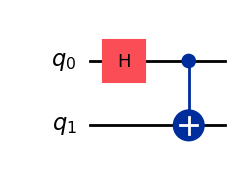

Statevector (Qiskit basis order |q1 q0> for two qubits): [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Counts: {'00': 496, '11': 528}


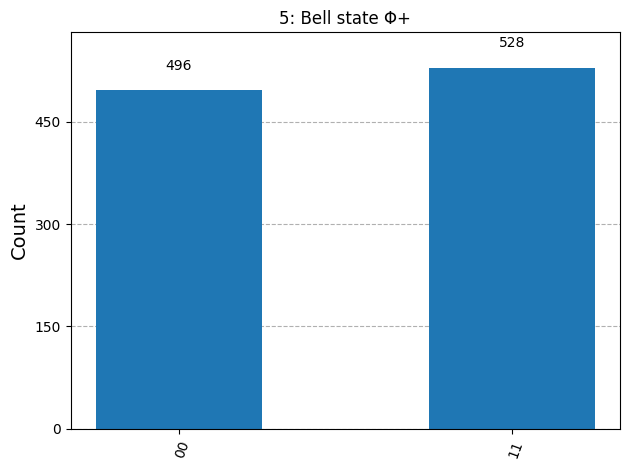

5: Bell state Φ-


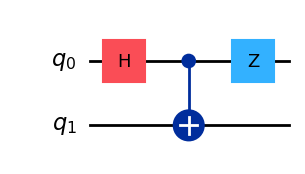

Statevector (Qiskit basis order |q1 q0> for two qubits): [ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]
Counts: {'00': 498, '11': 526}


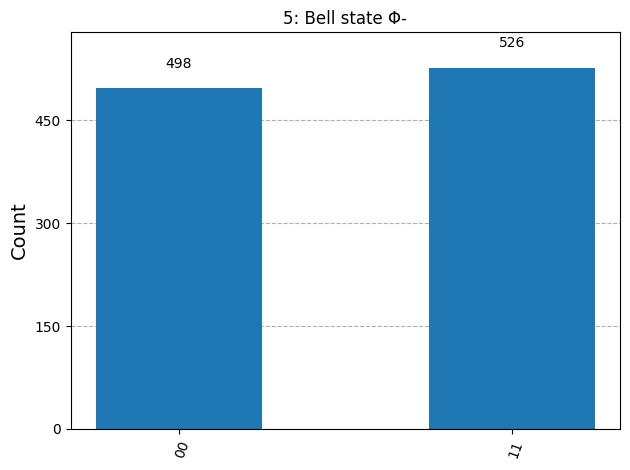

5: Bell state Ψ+


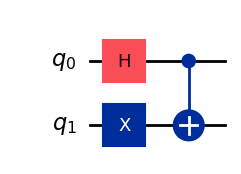

Statevector (Qiskit basis order |q1 q0> for two qubits): [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]
Counts: {'10': 516, '01': 508}


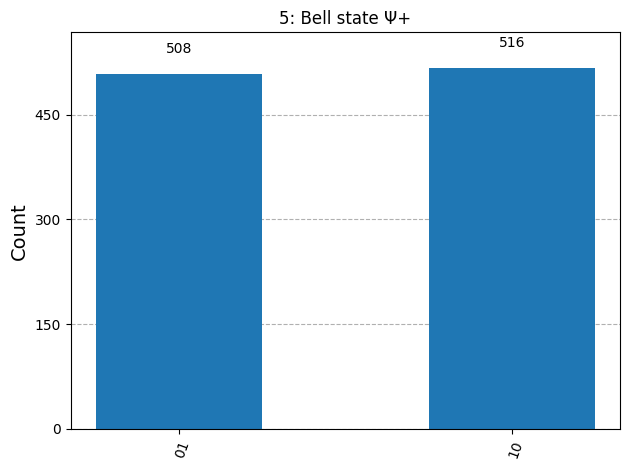

5: Bell state Ψ-


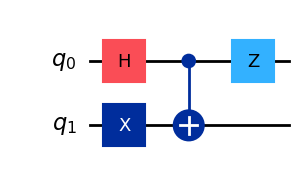

Statevector (Qiskit basis order |q1 q0> for two qubits): [ 0.        +0.j -0.70710678+0.j  0.70710678+0.j  0.        +0.j]
Counts: {'10': 520, '01': 504}


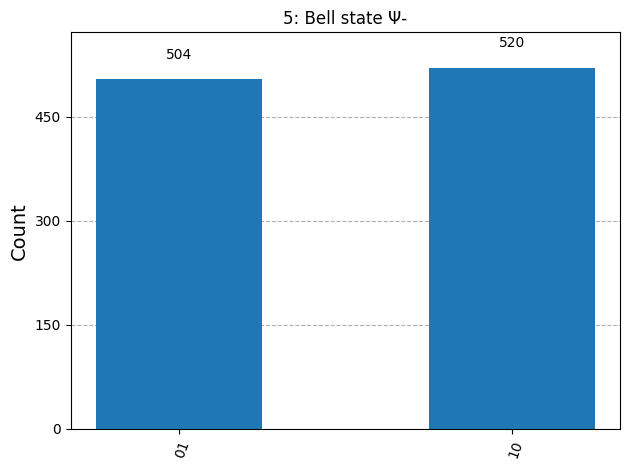


| Bell state | Statevector | Possible outcomes | Approx. probability |
|---|---|---|---|
| Φ+ | (|00> + |11>)/√2 | 00, 11 | 1/2 each |
| Φ- | (|00> - |11>)/√2 | 00, 11 | 1/2 each |
| Ψ+ | (|01> + |10>)/√2 | 01, 10 | 1/2 each |
| Ψ- | (|01> - |10>)/√2 | 01, 10 | 1/2 each |
|


**Why the probabilities match:** Φ+ and Φ- differ only in the relative sign of the |11> amplitude. Computational-basis measurement squares the magnitude of each amplitude, so +1/√2 and -1/√2 both give 1/2. Exactly the same reasoning applies to Ψ+ and Ψ-. The phase difference can be detected only with an interference-sensitive measurement basis or further gates.

In [9]:
def bell_circuit(label):
    qc = QuantumCircuit(2)
    if label == 'Φ+':
        qc.h(0); qc.cx(0, 1)
    elif label == 'Φ-':
        qc.h(0); qc.cx(0, 1); qc.z(0)
    elif label == 'Ψ+':
        qc.x(1); qc.h(0); qc.cx(0, 1)
    elif label == 'Ψ-':
        qc.x(1); qc.h(0); qc.cx(0, 1); qc.z(0)
    return qc

bell_results = {}
for label in ['Φ+', 'Φ-', 'Ψ+', 'Ψ-']:
    bell_results[label] = show_results(bell_circuit(label), f'5: Bell state {label}')

print('''
| Bell state | Statevector | Possible outcomes | Approx. probability |
|---|---|---|---|
| Φ+ | (|00> + |11>)/√2 | 00, 11 | 1/2 each |
| Φ- | (|00> - |11>)/√2 | 00, 11 | 1/2 each |
| Ψ+ | (|01> + |10>)/√2 | 01, 10 | 1/2 each |
| Ψ- | (|01> - |10>)/√2 | 01, 10 | 1/2 each |
|''')

display(Markdown('''**Why the probabilities match:** Φ+ and Φ- differ only in the relative sign of the |11> amplitude. Computational-basis measurement squares the magnitude of each amplitude, so +1/√2 and -1/√2 both give 1/2. Exactly the same reasoning applies to Ψ+ and Ψ-. The phase difference can be detected only with an interference-sensitive measurement basis or further gates.'''))

## 6. Entanglement Detective

Circuit 1 is the \(\Phi^+\) Bell circuit and is entangled. Circuit 2 is \(|+\rangle\otimes|+\rangle\), so it is separable. Circuit 3 ends in \(|-\rangle\otimes|+\rangle\), also separable: because the target is \(|+\rangle\), CNOT leaves it unchanged even though the control is in superposition. Thus correlated-looking results alone are never a sufficient test for entanglement.

In [ ]:
# Circuit 1
c1 = QuantumCircuit(2)
c1.h(0); c1.cx(0,1)
show_results(c1, '6.1: Circuit 1')
print('State: (|00> + |11>)/√2. Entangled.')

# Circuit 2
c2 = QuantumCircuit(2)
c2.h(0); c2.h(1)
show_results(c2, '6.2: Circuit 2')
print('State: |+>⊗|+>. Separable.')

# Circuit 3
c3 = QuantumCircuit(2)
c3.x(0); c3.h(0); c3.h(1); c3.cx(0,1)
show_results(c3, '6.3: Circuit 3')
print('State: |->⊗|+>. Separable; CNOT does not entangle a target in |+>.')

## 7. Conceptual Questions

**Q1.** A single-qubit superposition is one qubit in a linear combination such as \(\alpha|0\rangle+\beta|1\rangle\). A two-qubit entangled state has joint amplitudes that cannot be written as a product of separate one-qubit states. Entanglement creates correlations that remain even when each qubit alone looks random.

**Q2.** CNOT conditionally flips the target qubit when the control is `1`. After a Hadamard puts the control into superposition, CNOT correlates the two branches, transforming \((|00\rangle+|10\rangle)/\sqrt2\) into a Bell state. It is the two-qubit interaction that makes entanglement possible.

**Q3.** Measurement probabilities depend on squared amplitude magnitudes, not on their signs or phases. Thus two states such as \((|00\rangle+|11\rangle)/\sqrt2\) and \((|00\rangle-|11\rangle)/\sqrt2\) have identical computational-basis probabilities. Their relative phases can nevertheless affect interference in another basis.

**Q4.** A `Statevector` is the complete complex-amplitude description of an ideal quantum state before measurement. Measurement counts are sampled classical outcomes from repeated shots after measurement. Counts approximate probabilities, whereas a statevector gives exact amplitudes in the simulator.

**Q5.** One qubit has 2 computational-basis states; two have 4; three have 8; and five have 32. In general, \(n\) qubits have \(2^n\) computational-basis states. Every extra qubit doubles the size of the joint state space.